# Data Preprocessing for Machine Learning

In the previous notebook, I explored the asthma drug efficacy dataset and identified several important issues for modeling:

- The target variable is a count outcome with many zero values.
- A binary version of the target is highly imbalanced.
- `patid` is an identifier and should not be used as a predictor.
- `previous_asthma_drugs` is constant across all patients and should be removed.
- Several charge-related variables are highly skewed.
- Some variables are binary indicators, while others are continuous or count-based.

In this notebook, I will prepare the dataset for machine learning by selecting features, removing non-informative columns, checking skewed variables, defining target variables, and creating train-test splits.

## Preprocessing Plan

The main preprocessing steps are:

1. Load the raw dataset.
2. Recreate the binary outcome variable `had_exacerbation`.
3. Remove columns that should not be used as predictors.
4. Separate features and target variables.
5. Review skewed charge variables and decide how to handle them.
6. Create train-test splits for both count prediction and binary classification.
7. Save processed datasets for later modeling notebooks.

I will keep the preprocessing steps transparent so that the modeling workflow is reproducible.

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
# Loading dataset

data_path = "../data/raw/DrugEfficacyDataset.csv"

df = pd.read_csv(data_path)

df.head()

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
0,1073754155,14,1,1,0,0,0,1,0,1,0,0,0.0845,1224.7675,1,314.0000,218.1300,0,0,7.1105,5.3851
1,1073799394,21,1,2,2,0,1,1,0,0,0,1,0.0845,20290.5343,0,0.0000,44.9800,0,0,9.9179,3.8062
2,1073854918,62,1,0,0,0,0,0,0,0,0,0,0.7384,2964.2542,4,480.0000,99.2600,0,0,7.9944,4.5977
3,1073898249,30,1,2,0,0,0,1,0,1,0,0,0.0845,3223.7088,0,0.0000,59.5800,0,1,8.0783,4.0873
4,1073913003,40,1,1,0,0,1,0,1,1,0,1,0.5068,1287.2544,2,689.0000,29.7900,0,0,7.1603,3.3942


In [3]:
# shape of it
df.shape

(18215, 21)

## Recreating Binary Outcome Variable

The original target variable is `post_index_exacerbations365`, which is a count of exacerbations in the year after treatment start.

For modeling, I will prepare two possible target variables:

- `post_index_exacerbations365`: count outcome for regression or count prediction
- `had_exacerbation`: binary outcome for classification

The binary outcome is defined as:

- `0`: no exacerbation
- `1`: at least one exacerbation

In [ ]:
# Recreating target variables
target_count = "post_index_exacerbations365"

df["had_exacerbation"] = (df[target_count] > 0).astype(int)

df[[target_count, "had_exacerbation"]].head()

,post_index_exacerbations365,had_exacerbation
0,0,0
1,2,1
2,0,0
3,0,0
4,0,0


In [5]:
# To confirm binary target

df["had_exacerbation"].value_counts(normalize=True) * 100

had_exacerbation
0   88.5205
1   11.4795
Name: proportion, dtype: float64

## Removing Non-Predictive or Non-Informative Columns

Based on the data understanding step:

- `patid` is a patient identifier and should not be used as a predictor.
- `previous_asthma_drugs` has only one unique value for all patients, so it cannot help the model distinguish between patients.

Therefore, I will remove these columns from the feature set.

In [ ]:
# keeping informmative columns only for modeling

cols_to_drop = [
    "patid",
    "previous_asthma_drugs"
]

df_model = df.drop(columns=cols_to_drop)

df_model.head()

,index_age,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge,had_exacerbation
0,14,1,0,0,0,1,0,1,0,0,0.0845,1224.7675,1,314.0000,218.1300,0,0,7.1105,5.3851,0
1,21,2,2,0,1,1,0,0,0,1,0.0845,20290.5343,0,0.0000,44.9800,0,0,9.9179,3.8062,1
2,62,0,0,0,0,0,0,0,0,0,0.7384,2964.2542,4,480.0000,99.2600,0,0,7.9944,4.5977,0
3,30,2,0,0,0,1,0,1,0,0,0.0845,3223.7088,0,0.0000,59.5800,0,1,8.0783,4.0873,0
4,40,1,0,0,1,0,1,1,0,1,0.5068,1287.2544,2,689.0000,29.7900,0,0,7.1603,3.3942,0


In [7]:
# Checking columns again

df_model.columns.tolist()

['index_age',
 'total_pre_index_cannisters_365',
 'post_index_exacerbations365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_days',
 'pre_asthma_charge',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female',
 'log_charges',
 'log_asthma_charge',
 'had_exacerbation']

## Define Feature Matrix and Targets

I will define one feature matrix `X` and two target variables:

- `y_count`: original count outcome
- `y_binary`: binary exacerbation outcome

The feature matrix should not include either target variable.

In [8]:
# Separating features and targets

target_binary = "had_exacerbation"

X = df_model.drop(columns=[target_count, target_binary])
y_count = df_model[target_count]
y_binary = df_model[target_binary]

print("X shape:", X.shape)
print("y_count shape:", y_count.shape)
print("y_binary shape:", y_binary.shape)

X shape: (18215, 18)
y_count shape: (18215,)
y_binary shape: (18215,)


In [9]:
# checking final feature columns

X.columns.tolist()

['index_age',
 'total_pre_index_cannisters_365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_days',
 'pre_asthma_charge',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female',
 'log_charges',
 'log_asthma_charge']

## Feature Matrix and Target Setup Observation

After removing `patid` and `previous_asthma_drugs`, the modeling dataset contains **18 predictors**.

The feature matrix `X` has shape **18,215 × 18**, meaning there are 18,215 patient records and 18 input features available for modeling.

I also created two target variables:

- `y_count`: the original count outcome, `post_index_exacerbations365`
- `y_binary`: the binary outcome, `had_exacerbation`

This setup allows me to explore two related modeling approaches later:

1. Predicting the number of exacerbations.
2. Predicting whether a patient had at least one exacerbation.

Before creating train-test splits, I need to examine the predictor variables more carefully, especially the charge-related variables, because they are highly skewed and may contain extreme values.

## Review of Charge-Related Variables

The dataset contains several healthcare charge variables. From the first notebook, I observed that some of these variables are highly skewed, with very large maximum values.

The dataset also includes log-transformed versions of two charge variables:

- `total_pre_index_charge` and `log_charges`
- `pre_asthma_charge` and `log_asthma_charge`

Before modeling, I want to compare the raw and log-transformed charge variables. If the raw variables are extremely skewed, the log-transformed versions may be more stable for some models.

In [10]:
# Charge variable summary
charge_cols = [
    "total_pre_index_charge",
    "pre_asthma_charge",
    "pre_asthma_pharma_charge",
    "log_charges",
    "log_asthma_charge"
]

df[charge_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_pre_index_charge,18215.0000,8524.8350,21011.1237,1.0000,1227.0349,3154.9410,8142.1238,875872.5806
pre_asthma_charge,18215.0000,547.8948,1940.9533,0.0000,0.0000,130.0000,410.0850,79280.9100
pre_asthma_pharma_charge,18215.0000,244.8202,448.7719,1.0000,21.4100,46.3000,229.5600,5463.1400
log_charges,18215.0000,7.9842,1.6490,0.0000,7.1124,8.0567,9.0048,13.6830
log_asthma_charge,18215.0000,4.2001,1.7104,0.0000,3.0639,3.8351,5.4362,8.6058


In [11]:
# Skewness of charge variables

df[charge_cols].skew().sort_values(ascending=False)

total_pre_index_charge     14.1220
pre_asthma_charge          13.4814
pre_asthma_pharma_charge    3.4702
log_asthma_charge          -0.0018
log_charges                -1.2222
dtype: float64

In [12]:
# LEts check correlation Between Raw and Log Charge Variables

charge_corr = df[
    [
        "total_pre_index_charge",
        "log_charges",
        "pre_asthma_charge",
        "log_asthma_charge",
        "pre_asthma_pharma_charge"
    ]
].corr()

charge_corr

,total_pre_index_charge,log_charges,pre_asthma_charge,log_asthma_charge,pre_asthma_pharma_charge
total_pre_index_charge,1.0000,0.5062,0.1933,-0.0188,-0.0064
log_charges,0.5062,1.0000,0.2133,-0.0007,0.0220
pre_asthma_charge,0.1933,0.2133,1.0000,0.0827,0.1048
log_asthma_charge,-0.0188,-0.0007,0.0827,1.0000,0.7367
pre_asthma_pharma_charge,-0.0064,0.0220,0.1048,0.7367,1.0000


In [13]:
# Plotting Raw vs Log Charge Distributions
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

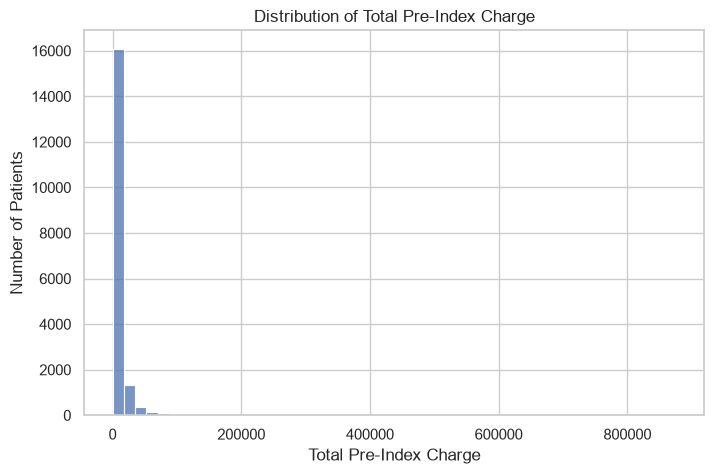

In [15]:
# Distribution of Total Pre-Index Charge
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="total_pre_index_charge",
    bins=50
)

plt.title("Distribution of Total Pre-Index Charge")
plt.xlabel("Total Pre-Index Charge")
plt.ylabel("Number of Patients")
plt.show()

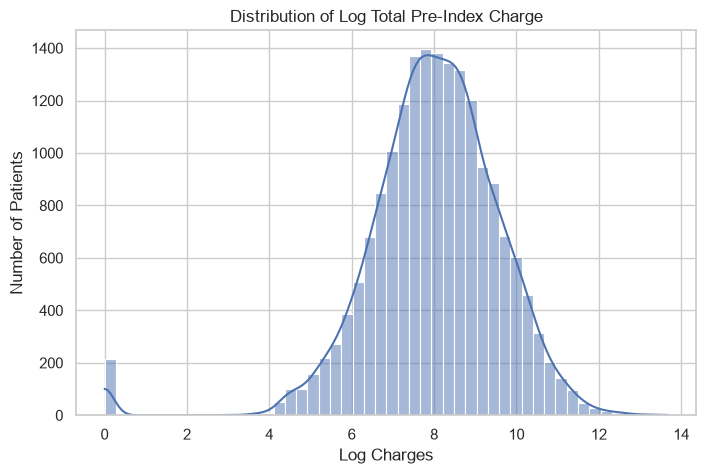

In [16]:
# Distribution of Log Total Pre-Index Charge

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="log_charges",
    bins=50,
    kde=True
)

plt.title("Distribution of Log Total Pre-Index Charge")
plt.xlabel("Log Charges")
plt.ylabel("Number of Patients")
plt.show()

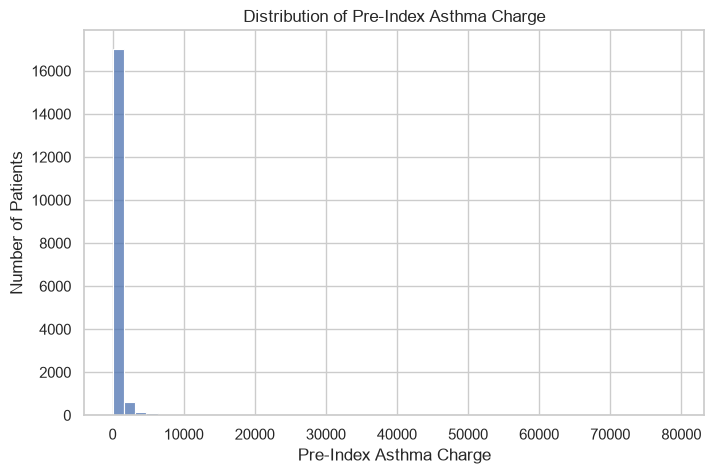

In [17]:
# Distribution of Pre-Index Asthma Charge

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="pre_asthma_charge",
    bins=50
)

plt.title("Distribution of Pre-Index Asthma Charge")
plt.xlabel("Pre-Index Asthma Charge")
plt.ylabel("Number of Patients")
plt.show()

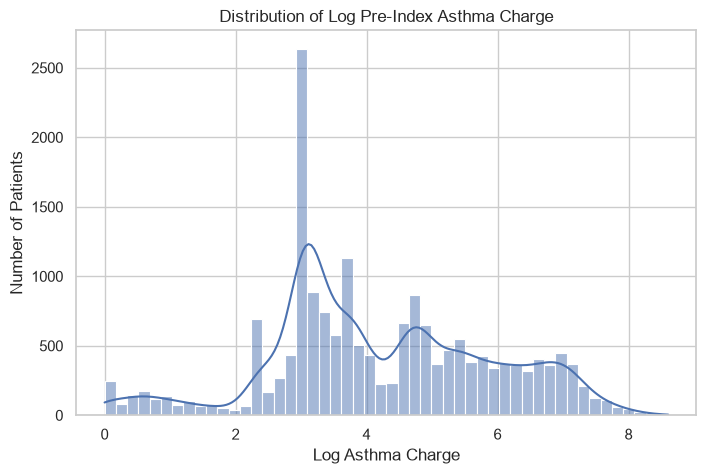

In [18]:
# Distribution of Log Pre-Index Asthma Charge

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="log_asthma_charge",
    bins=50,
    kde=True
)

plt.title("Distribution of Log Pre-Index Asthma Charge")
plt.xlabel("Log Asthma Charge")
plt.ylabel("Number of Patients")
plt.show()

The raw charge variables show strong right skewness. This means most patients have relatively low or moderate charges, while a smaller number of patients have very high charges.

This is common in healthcare claims data because a small number of patients may have very high healthcare utilization or severe disease burden.

The log-transformed variables, `log_charges` and `log_asthma_charge`, appear more compressed and less extreme than their raw versions. This may make them more useful for linear models or distance-based models.

However, tree-based models such as Random Forest or XGBoost can often handle skewed variables better than linear models. Therefore, I may compare modeling approaches later.

At this stage, I need to decide whether to keep both raw and log-transformed versions or create separate feature sets for comparison.

## Creating Two Feature Sets

In [19]:
# Feature set A: keep raw charge variables, drop log-transformed charge variables
X_raw_charge = X.drop(columns=[
    "log_charges",
    "log_asthma_charge"
])

# Feature set B: keep log-transformed charge variables, drop raw charge variables
X_log_charge = X.drop(columns=[
    "total_pre_index_charge",
    "pre_asthma_charge"
])

print("X_raw_charge shape:", X_raw_charge.shape)
print("X_log_charge shape:", X_log_charge.shape)

X_raw_charge shape: (18215, 16)
X_log_charge shape: (18215, 16)


In [22]:
# Checking Feature Columns set with raw charges
X_raw_charge.columns.tolist()

['index_age',
 'total_pre_index_cannisters_365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_days',
 'pre_asthma_charge',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female']

In [23]:
# Checking Feature Columns set with log charges
X_log_charge.columns.tolist()

['index_age',
 'total_pre_index_cannisters_365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'pre_asthma_days',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female',
 'log_charges',
 'log_asthma_charge']

## Observation: Charge Variable Skewness and Feature Set Choice

The raw healthcare charge variables are highly right-skewed. For example, `total_pre_index_charge` has a median of about **3,155** but a maximum value above **875,000**. Similarly, `pre_asthma_charge` has a median of **130** but a maximum above **79,000**.

The skewness values confirm this pattern:

- `total_pre_index_charge`: **14.12**
- `pre_asthma_charge`: **13.48**
- `pre_asthma_pharma_charge`: **3.47**

This suggests that a small number of patients had very high healthcare costs, which is common in healthcare claims data. These extreme values could strongly influence models such as linear regression or logistic regression.

The log-transformed variables are much less skewed:

- `log_asthma_charge`: approximately **0.00**
- `log_charges`: **−1.22**

Because of this, the log-transformed charge variables may be more stable for the first modeling workflow.

I also checked correlations among the charge variables. One notable relationship is between `pre_asthma_pharma_charge` and `log_asthma_charge`, with a correlation of about **0.74**. This indicates that these variables share related information, although they are not identical.

To avoid mixing raw and log-transformed versions of the same charge information, I created two feature sets:

- `X_raw_charge`: keeps raw charge variables and removes log-transformed charge variables.
- `X_log_charge`: keeps log-transformed charge variables and removes the corresponding raw charge variables.

For the first modeling notebook, I will use `X_log_charge` as the main feature set because it reduces the effect of extreme raw charge values. The raw-charge feature set can be kept for later sensitivity analysis.

## Train-Test Split

Before modeling, I need to split the data into training and test sets.

The training set will be used to fit the models, while the test set will be held out for final evaluation. This helps estimate how well the models may perform on new, unseen patients.

Because the binary outcome `had_exacerbation` is imbalanced, I will use stratified splitting based on this binary target. This keeps the proportion of patients with and without exacerbations similar in both the training and test sets.

For the first modeling workflow, I will use the `X_log_charge` feature set.

In [24]:
# Train-Test splitting

# Using the log-charge feature set as the main modeling feature matrix
X_main = X_log_charge.copy()

# Create train-test split
X_train, X_test, y_count_train, y_count_test, y_binary_train, y_binary_test = train_test_split(
    X_main,
    y_count,
    y_binary,
    test_size=0.20,
    random_state=22,
    stratify=y_binary
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_count_train shape:", y_count_train.shape)
print("y_count_test shape:", y_count_test.shape)
print("y_binary_train shape:", y_binary_train.shape)
print("y_binary_test shape:", y_binary_test.shape)

X_train shape: (14572, 16)
X_test shape: (3643, 16)
y_count_train shape: (14572,)
y_count_test shape: (3643,)
y_binary_train shape: (14572,)
y_binary_test shape: (3643,)


In [25]:
# Checking Binary Class Balance

train_binary_balance = y_binary_train.value_counts(normalize=True).sort_index() * 100
test_binary_balance = y_binary_test.value_counts(normalize=True).sort_index() * 100

balance_check = pd.DataFrame({
    "train_percent": train_binary_balance,
    "test_percent": test_binary_balance
})

balance_check

,train_percent,test_percent
had_exacerbation,,
0,88.5191,88.5259
1,11.4809,11.4741


In [26]:
# Lets also check Count Target Summary in Train and Test

count_target_split_summary = pd.DataFrame({
    "train": y_count_train.describe(),
    "test": y_count_test.describe()
})

count_target_split_summary

,train,test
count,14572.0000,3643.0000
mean,0.1732,0.1803
std,0.6242,0.6687
min,0.0000,0.0000
25%,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,0.0000
max,13.0000,14.0000


## Observation: Train-Test Split

The dataset was split into training and test sets using an 80/20 split.

The training set contains **14572 patients**, and the test set contains **3643 patients**. I used stratification based on the binary outcome `had_exacerbation`, which kept the class distribution almost identical in both sets.

The percentage of patients with at least one exacerbation was:

- **Training set:** 11.48%
- **Test set:** 11.47%

This is important because the positive class is relatively small. Without stratification, the test set could accidentally contain a different exacerbation rate, which would make model evaluation less reliable.

The count outcome distribution is also similar between the training and test sets. The mean exacerbation count was **0.1732** in the training set and **0.1803** in the test set. Both sets have a median of **0**, confirming that the zero-heavy nature of the outcome is preserved after splitting.

This split will be used for both the binary classification task and the count-prediction task so that model comparisons are based on the same patient groups.

## Saving Processed Train-Test Datasets

After creating the train-test split, I will save the processed datasets into the `data/processed/` folder.

This will make the project more organized and reproducible. Later modeling notebooks can directly load these processed files instead of repeating all preprocessing steps.

In [28]:
# To save processed train-test datasets

X_train.to_csv("../data/processed/X_train_log.csv", index=False)
X_test.to_csv("../data/processed/X_test_log.csv", index=False)

y_count_train.to_csv("../data/processed/y_count_train.csv", index=False)
y_count_test.to_csv("../data/processed/y_count_test.csv", index=False)

y_binary_train.to_csv("../data/processed/y_binary_train.csv", index=False)
y_binary_test.to_csv("../data/processed/y_binary_test.csv", index=False)

In [29]:
import os

processed_dir = "../data/processed"

os.listdir(processed_dir)

['X_test_log.csv',
 'X_train_log.csv',
 'y_binary_test.csv',
 'y_binary_train.csv',
 'y_count_test.csv',
 'y_count_train.csv']

## Processed Dataset Saving Observation

The processed train-test datasets were saved successfully in the `data/processed/` folder.

The saved files are:

- `X_train_log.csv`
- `X_test_log.csv`
- `y_count_train.csv`
- `y_count_test.csv`
- `y_binary_train.csv`
- `y_binary_test.csv`

These files will be used in the next modeling notebooks. Saving the processed data helps separate preprocessing from modeling and makes the workflow easier to reproduce.

# Summary of Preprocessing Decisions

In this notebook, I prepared the asthma drug efficacy dataset for machine learning modeling.

The main preprocessing decisions were:

1. Created a binary outcome variable, `had_exacerbation`, from the original count outcome.
2. Removed `patid` because it is only a patient identifier.
3. Removed `previous_asthma_drugs` because it is constant across all patients.
4. Created two possible feature sets:
   - `X_raw_charge`: includes raw charge variables.
   - `X_log_charge`: includes log-transformed charge variables.
5. Selected `X_log_charge` as the main feature set for initial modeling because the raw charge variables were highly skewed.
6. Created an 80/20 train-test split using stratification based on the binary outcome.
7. Saved the processed train-test files for later modeling.

The final main modeling feature set contains **16 predictors**. The training set contains **14,572 patients**, and the test set contains **3,643 patients**.

The next step is to begin baseline modeling. I will start with the binary classification task because identifying patients with at least one future exacerbation is clinically interpretable and useful.